# Customer Churn Prediction using Machine Learning

### Thiranex Data Science Internship - Task 2

**Author:** Obilipapannagari Sathwik Reddy

## Objective

The objective of this project is to build a machine learning model that predicts whether a customer is likely to leave the telecom company (churn) based on customer demographics, account information, and subscribed services.

## Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Engineering
7. Model Building
8. Model Evaluation
9. Feature Importance
10. Conclusion

## 1. Import Required Libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Dataset Overview

In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.head()

Rows : 7043
Columns : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Data Understanding

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.describe(include="str")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


## 5. Data Cleaning

In [8]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [9]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.isnull().sum()

Rows: 7032
Columns: 21


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [15]:
df.to_csv("../data/cleaned_customer_churn.csv", index=False)

## 6. Exploratory Data Analysis (EDA)

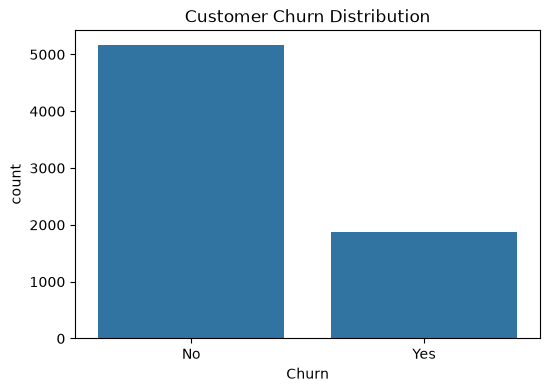

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.savefig("../images/churn_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [17]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


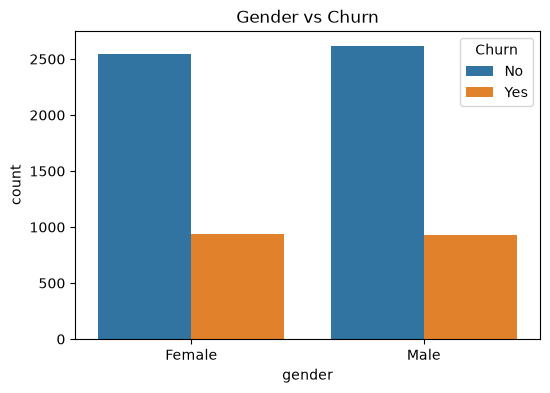

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Gender vs Churn")

plt.savefig("../images/gender_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

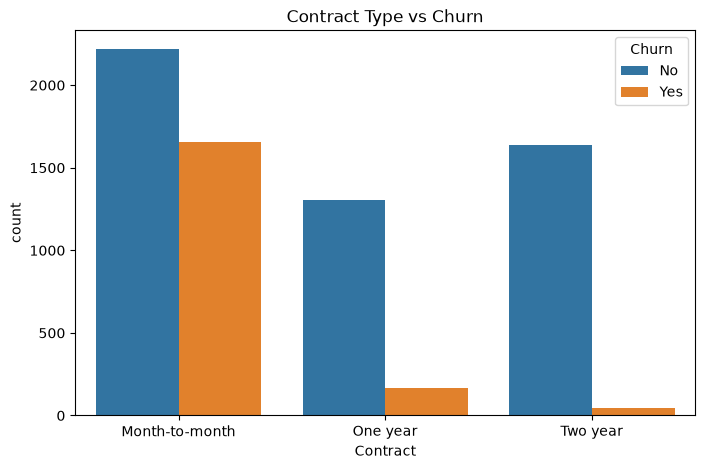

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Churn")

plt.savefig("../images/contract_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

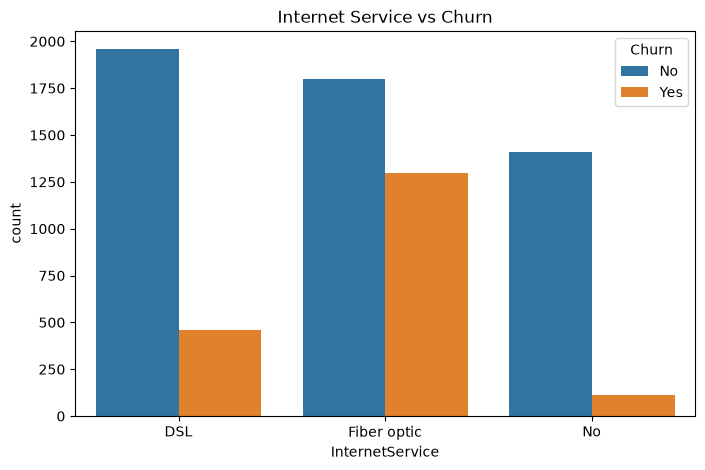

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Churn")

plt.savefig("../images/internet_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

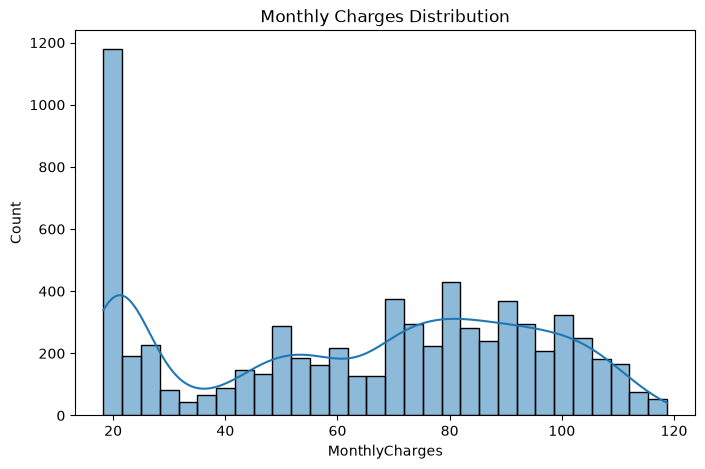

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Monthly Charges Distribution")

plt.savefig("../images/monthly_charges_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

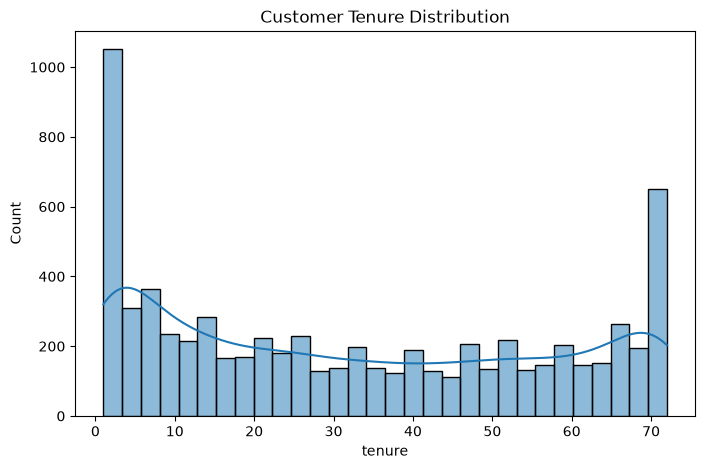

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Customer Tenure Distribution")

plt.savefig("../images/tenure_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## 7. Feature Engineering & Data Preprocessing

In [24]:
df.drop("customerID", axis=1, inplace=True)

In [25]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

In [26]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [27]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [28]:
X = pd.get_dummies(X, drop_first=True)

In [29]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (7032, 30)
Target Shape : (7032,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [32]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


## 8. Model Building

In [33]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [34]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [35]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

## 9. Model Evaluation

In [36]:
log_acc = accuracy_score(y_test, log_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

accuracy = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        log_acc,
        dt_acc,
        rf_acc
    ]
})

accuracy.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.803838
2,Random Forest,0.786780
1,Decision Tree,0.716418


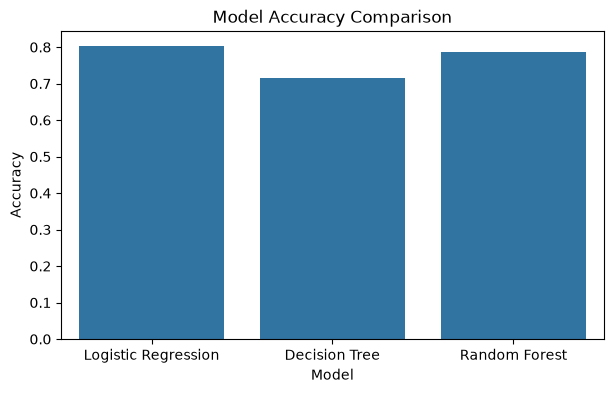

In [37]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=accuracy,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.savefig("../images/model_accuracy.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [38]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



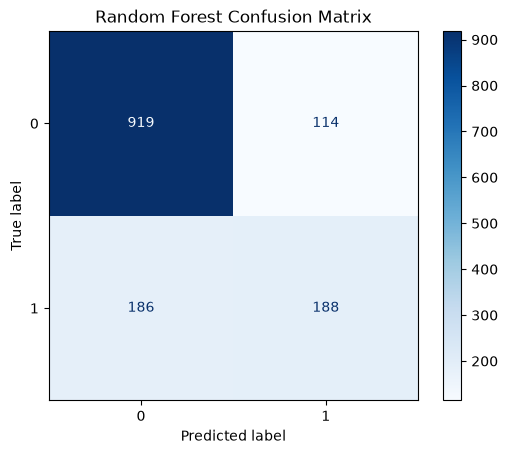

In [39]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.savefig("../images/confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [40]:
print(accuracy)

                 Model  Accuracy
0  Logistic Regression  0.803838
1        Decision Tree  0.716418
2        Random Forest  0.786780


## 10. ROC Curve

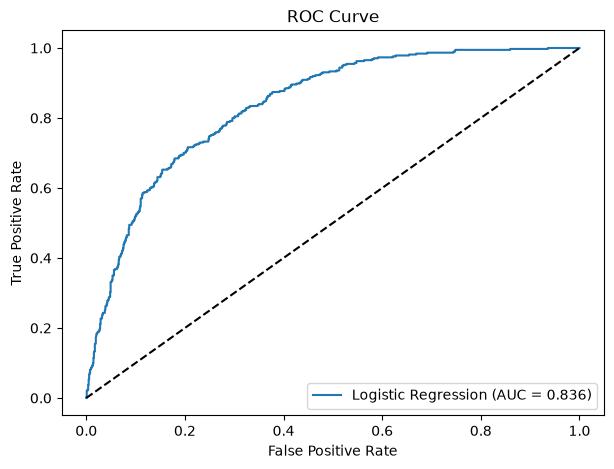

In [41]:
from sklearn.metrics import roc_curve, auc

log_prob = log_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, log_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr,
         label=f"Logistic Regression (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig("../images/roc_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## 11. Feature Importance

In [42]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.194313
1,tenure,0.168529
2,MonthlyCharges,0.167972
10,InternetService_Fiber optic,0.038913
28,PaymentMethod_Electronic check,0.037898
25,Contract_Two year,0.031862
4,gender_Male,0.028939
13,OnlineSecurity_Yes,0.027288
26,PaperlessBilling_Yes,0.025595
5,Partner_Yes,0.023280


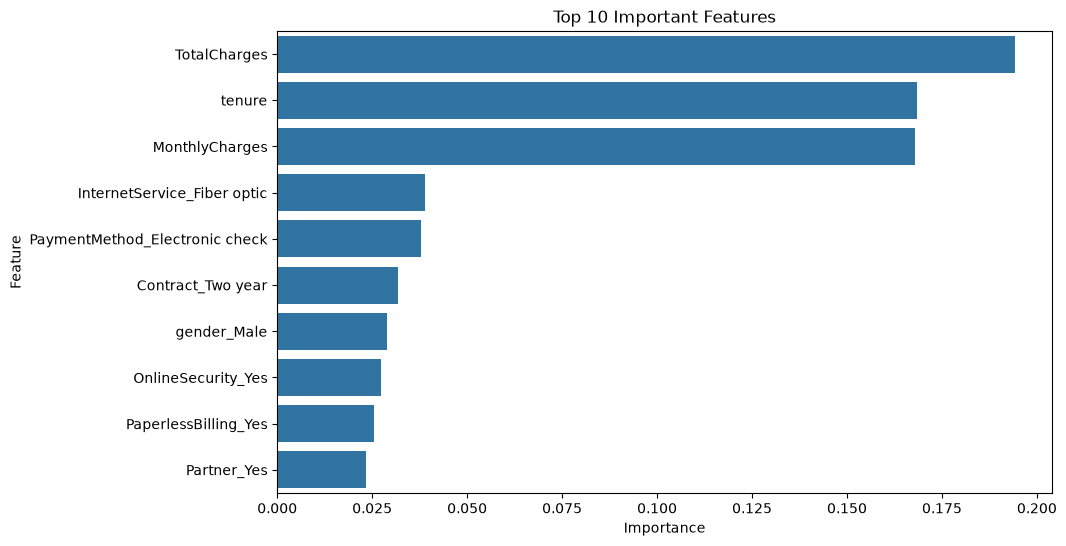

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.savefig("../images/feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [45]:
import joblib

joblib.dump(log_model, "../models/customer_churn_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

## 12. Conclusion

### Conclusion

- Successfully built a customer churn prediction model using machine learning.
- Cleaned and preprocessed the dataset by handling missing values and encoding categorical features.
- Performed exploratory data analysis to understand customer behavior.
- Compared three classification models:
  - Logistic Regression
  - Decision Tree
  - Random Forest
- Logistic Regression achieved the highest accuracy of **80.38%**, making it the best-performing model for this dataset.
- Feature importance analysis showed which customer attributes contributed most to churn prediction.
- This project demonstrates a complete end-to-end machine learning workflow from data preprocessing to model evaluation.

## Future Improvements

- Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Address class imbalance using SMOTE or class weighting.
- Try gradient boosting models such as XGBoost, LightGBM, or CatBoost.
- Deploy the trained model using Streamlit or Flask.
- Monitor model performance with new customer data over time.